In [1]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.getOrCreate()

In [8]:
def mariadb_connect(df, table_name):
    df.write \
        .format("jdbc") \
        .option("driver", "org.mariadb.jdbc.Driver") \
        .option("url", "jdbc:mysql://localhost:3306/retails?permitMysqlScheme") \
        .option("dbtable", table_name) \
        .option("user", "root") \
        .option("password", "Thanhdan@123") \
        .mode("overwrite") \
        .save()

In [9]:
# -----------------------------------------------
# 1. BẢNG orders
# -----------------------------------------------
orders_df = spark.read.json(f"hdfs://localhost:9000//retails/orders/part-r-00000-990f5773-9005-49ba-b670-631286032674")
orders_df.show(2)
mariadb_connect(orders_df, "orders")

+-----------------+--------------------+--------+---------------+
|order_customer_id|          order_date|order_id|   order_status|
+-----------------+--------------------+--------+---------------+
|            11599|2013-07-25 00:00:...|       1|         CLOSED|
|              256|2013-07-25 00:00:...|       2|PENDING_PAYMENT|
+-----------------+--------------------+--------+---------------+
only showing top 2 rows


In [10]:
# -----------------------------------------------
# 2. BẢNG order_items
# -----------------------------------------------
order_items_df = spark.read.json(f"hdfs://localhost:9000//retails/order_items/part-r-00000-6b83977e-3f20-404b-9b5f-29376ab1419e")
order_items_df.show(2)
mariadb_connect(order_items_df, "order_items")

+-------------+-------------------+---------------------+------------------------+-------------------+-------------------+
|order_item_id|order_item_order_id|order_item_product_id|order_item_product_price|order_item_quantity|order_item_subtotal|
+-------------+-------------------+---------------------+------------------------+-------------------+-------------------+
|            1|                  1|                  957|                  299.98|                  1|             299.98|
|            2|                  2|                 1073|                  199.99|                  1|             199.99|
+-------------+-------------------+---------------------+------------------------+-------------------+-------------------+
only showing top 2 rows


In [11]:
# -----------------------------------------------
# 3. BẢNG customers
# -----------------------------------------------
customers_df = spark.read.json(f"hdfs://localhost:9000//retails/customers/part-r-00000-70554560-527b-44f6-9e80-4e2031af5994")
customers_df.show(2)
mariadb_connect(customers_df, "customers")

+-------------+--------------+--------------+-----------+--------------+-----------------+--------------+--------------------+----------------+
|customer_city|customer_email|customer_fname|customer_id|customer_lname|customer_password|customer_state|     customer_street|customer_zipcode|
+-------------+--------------+--------------+-----------+--------------+-----------------+--------------+--------------------+----------------+
|  Brownsville|     XXXXXXXXX|       Richard|          1|     Hernandez|        XXXXXXXXX|            TX|  6303 Heather Plaza|           78521|
|    Littleton|     XXXXXXXXX|          Mary|          2|       Barrett|        XXXXXXXXX|            CO|9526 Noble Embers...|           80126|
+-------------+--------------+--------------+-----------+--------------+-----------------+--------------+--------------------+----------------+
only showing top 2 rows


In [12]:
# -----------------------------------------------
# 4. BẢNG products
# -----------------------------------------------
products_df = spark.read.json(f"hdfs://localhost:9000//retails/products/part-r-00000-158b7037-4a23-47e6-8cb3-8cbf878beff7")
products_df.show(2)
mariadb_connect(products_df, "products")

+-------------------+-------------------+----------+--------------------+--------------------+-------------+
|product_category_id|product_description|product_id|       product_image|        product_name|product_price|
+-------------------+-------------------+----------+--------------------+--------------------+-------------+
|                  2|                   |         1|http://images.acm...|Quest Q64 10 FT. ...|        59.98|
|                  2|                   |         2|http://images.acm...|Under Armour Men'...|       129.99|
+-------------------+-------------------+----------+--------------------+--------------------+-------------+
only showing top 2 rows


In [13]:
# -----------------------------------------------
# 5. BẢNG categories
# -----------------------------------------------
categories_df = spark.read.json(f"hdfs://localhost:9000//retails/categories/part-r-00000-ce1d8208-178d-48d3-bfb2-1a97d9c05094")
categories_df.show(2)
mariadb_connect(categories_df, "categories")

+----------------------+-----------+-------------+
|category_department_id|category_id|category_name|
+----------------------+-----------+-------------+
|                     2|          1|     Football|
|                     2|          2|       Soccer|
+----------------------+-----------+-------------+
only showing top 2 rows


In [14]:
# -----------------------------------------------
# 6. BẢNG departments
# -----------------------------------------------
departments_df = spark.read.json(f"hdfs://localhost:9000//retails/departments/part-r-00000-3db7cfae-3ad2-4fc7-88ff-afe0ec709f49")
departments_df.show(2)
mariadb_connect(departments_df, "departments")

+-------------+---------------+
|department_id|department_name|
+-------------+---------------+
|            2|        Fitness|
|            3|       Footwear|
+-------------+---------------+
only showing top 2 rows


In [16]:
df = spark.read \
    .format("jdbc") \
    .option("driver", "org.mariadb.jdbc.Driver") \
    .option("url", "jdbc:mysql://localhost:3306/retails?permitMysqlScheme") \
    .option("dbtable", "order_items") \
    .option("user", "root") \
    .option("password", "Thanhdan@123") \
    .load()

In [19]:
df.printSchema()

root
 |-- order_item_id: long (nullable = true)
 |-- order_item_order_id: long (nullable = true)
 |-- order_item_product_id: long (nullable = true)
 |-- order_item_product_price: double (nullable = true)
 |-- order_item_quantity: long (nullable = true)
 |-- order_item_subtotal: double (nullable = true)



In [20]:
df.createOrReplaceTempView("order_items")

# Exercise 7
Let us validate if we have an invalid order_item_subtotal as part of the order_items table.
* The order_items table has 6 fields.
* order_item_id
* order_item_order_id
* order_item_product_id
* order_item_quantity
* order_item_subtotal
* order_item_product_price
* order_item_subtotal is nothing but the product of order_item_quantity and order_item_product_price. It means order_item_subtotal is computed by multiplying order_item_quantity and order_item_product_price for each item.
* You need to get the count of order_items where order_item_subtotal is not equal to the
product of order_item_quantity and order_item_product_price.
* There can be issues related to rounding off. Make sure it is taken care of using the
appropriate function.

The output should be 0 as there are no such records.
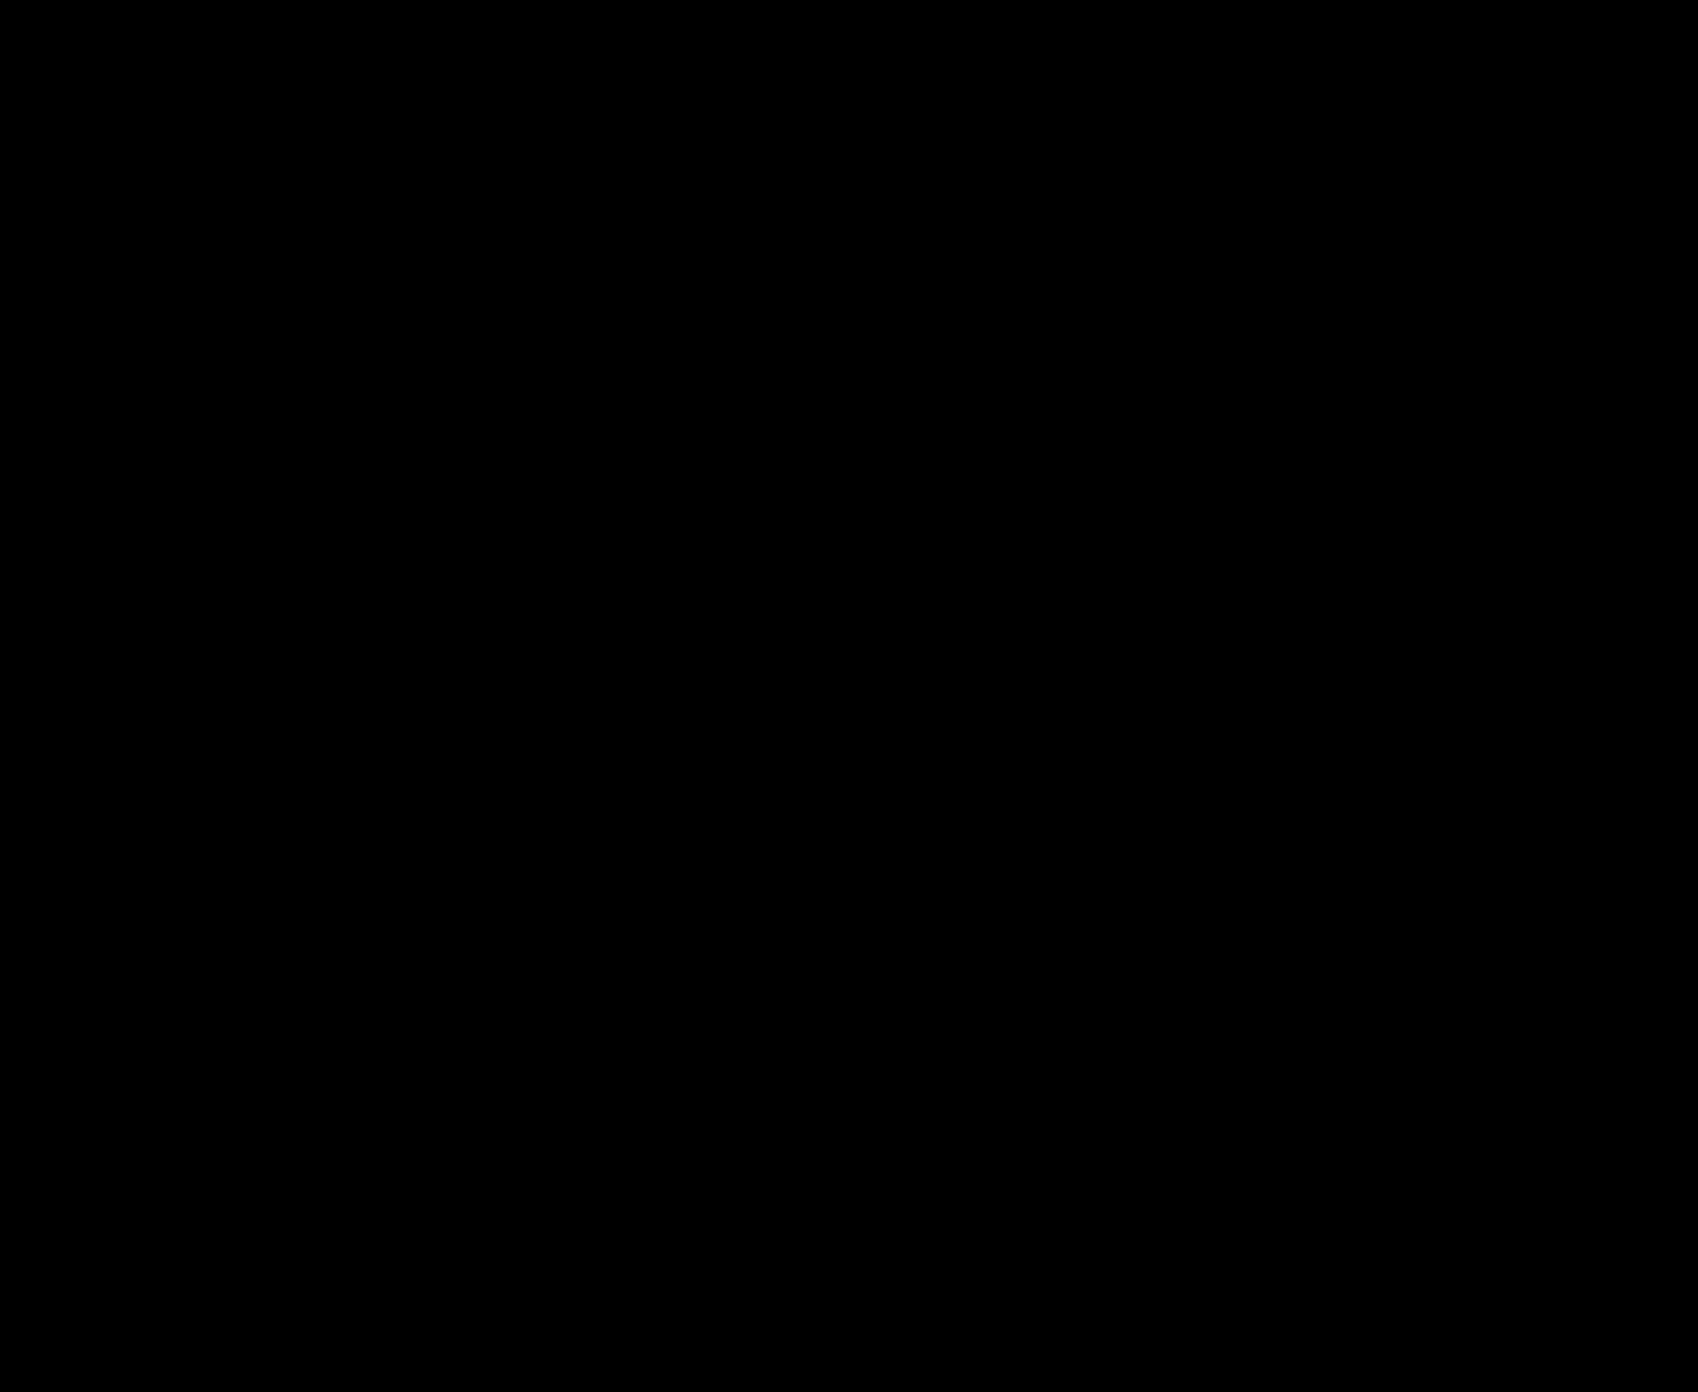

In [22]:
spark.sql("""
    select count(*) as invalid_count
    from order_items
    where round(order_item_subtotal, 2) != round(order_item_quantity * order_item_product_price, 2)
""").show()

+-------------+
|invalid_count|
+-------------+
|            0|
+-------------+



# Exercise 8
Get the number of orders placed on weekdays and weekends in the month of January 2014.
* Orders have 4 fields: order_id, order_date, order_customer_id, order_status
* Use the order date to determine the day on which orders are placed.
* Output should contain 2 columns - day_type and order_count.
* day_type should have 2 values: Week days and Weekend days.

Here is the desired output.

In [23]:
df1 = spark.read \
    .format("jdbc") \
    .option("driver", "org.mariadb.jdbc.Driver") \
    .option("url", "jdbc:mysql://localhost:3306/retails?permitMysqlScheme") \
    .option("dbtable", "orders") \
    .option("user", "root") \
    .option("password", "Thanhdan@123") \
    .load()

df1.printSchema()

root
 |-- order_customer_id: long (nullable = true)
 |-- order_date: string (nullable = true)
 |-- order_id: long (nullable = true)
 |-- order_status: string (nullable = true)



In [24]:
df1.createOrReplaceTempView("orders")

In [39]:
df1.count()

68883

In [40]:
spark.sql("""
    select
        case
            when weekday(order_date) >= 5 then 'Weekend days'
            else 'Week days' end as day_type,
        count(*) as order_count
    from orders
    group by day_type
""").show()

+------------+-----------+
|    day_type|order_count|
+------------+-----------+
|Weekend days|      19719|
|   Week days|      49164|
+------------+-----------+

